In [9]:
%reload_ext autoreload
%autoreload 2
import sys
from pathlib import Path
from typing import Any, Optional, Literal

# Add benchmark-app to the path so we can import bench modules
BENCHMARK_APP_DIR = Path("__file__").resolve().parent.parent
if str(BENCHMARK_APP_DIR) not in sys.path:
    sys.path.insert(0, str(BENCHMARK_APP_DIR))
BASELINES_DIR = BENCHMARK_APP_DIR / "baselines-results"
TORCHRUNS_DIR = BENCHMARK_APP_DIR.parent / "torchdecoder" / "runs"

In [10]:
import matplotlib.pyplot as plt

import plot_utils

%matplotlib inline
plt.rcParams.update({"figure.figsize": (10, 6), "font.size": 12, "pdf.fonttype": 42})

In [12]:
from bench.custom_bench.stats import BenchmarkStats
from bench.params import QECParams
from bench.constants import ALL_BASELINE_DECODERS

# 1. Helper functions

In [13]:
def load_stats(
    *,
    qec_params: QECParams,
    decoder_name_to_kwargs: dict[str, list[dict[str, Any]]],
    physical_error_rates: list[float],
) -> list[BenchmarkStats]:
    baselines_subdir = (
        BASELINES_DIR
        / f"{qec_params.code}_{qec_params.noise_model}"
        / f"d={qec_params.d}_rounds={qec_params.rounds}_basis={qec_params.basis}"
    )
    torchruns_subdir = (
        TORCHRUNS_DIR
        / f"{qec_params.code}_{qec_params.noise_model}"
        / f"d={qec_params.d}_rounds={qec_params.rounds}_basis={qec_params.basis}"
    )
    filtered_stats: list[BenchmarkStats] = []
    for decoder_name, decoder_kwargs_list in decoder_name_to_kwargs.items():
        if decoder_name in ALL_BASELINE_DECODERS:
            csv_path = baselines_subdir / decoder_name / "custom_benchmark.csv"
        else:
            decoder_name_splits = decoder_name.split("/")
            assert len(decoder_name_splits) == 2
            csv_path = (
                torchruns_subdir
                / decoder_name_splits[0]
                / decoder_name_splits[1]
                / "custom_benchmark.csv"
            )
        all_stats = BenchmarkStats.load_csv(csv_path)
        for s in all_stats:
            m = s.metadata
            if m.p not in physical_error_rates:
                continue
            if m.decoder_params not in decoder_kwargs_list:
                continue
            filtered_stats.append(s)
    return filtered_stats


def plot_fr_vs_iter_budget(
    stats: list[BenchmarkStats],
    *,
    qec_params: QECParams,
    x_metric: Literal["iter_budget", "avg_iter"],
    y_metric: Literal["fr_per_shot", "fr_per_round"],
    suptitle: Optional[str] = None,
    save_at: Optional[str | Path] = None,
):
    def label_fn(s: BenchmarkStats) -> str:
        lb = s.metadata.decoder_name
        if lb == "RelayBP":
            lb += f"(N={s.metadata.decoder_params['num_indep_decoders']})"
        return lb

    fig, ax = plt.subplots()
    plot_utils.plot_fr_vs_iter_budget(
        stats,
        ax,
        budget_step=50,
        x_metric=x_metric,
        y_metric=y_metric,
        label_fn=label_fn,
        title=f"{qec_params.code}, {qec_params.noise_model}",
    )
    if suptitle:
        fig.suptitle(suptitle, fontsize=plot_utils.SUPTITLE_FONTSIZE)
    fig.tight_layout()
    if save_at:
        fig.savefig(save_at)
    plt.show()

# 2. Gross code, circuit-level, basis=Z, p=0.001

Loaded 4 benchmark entries


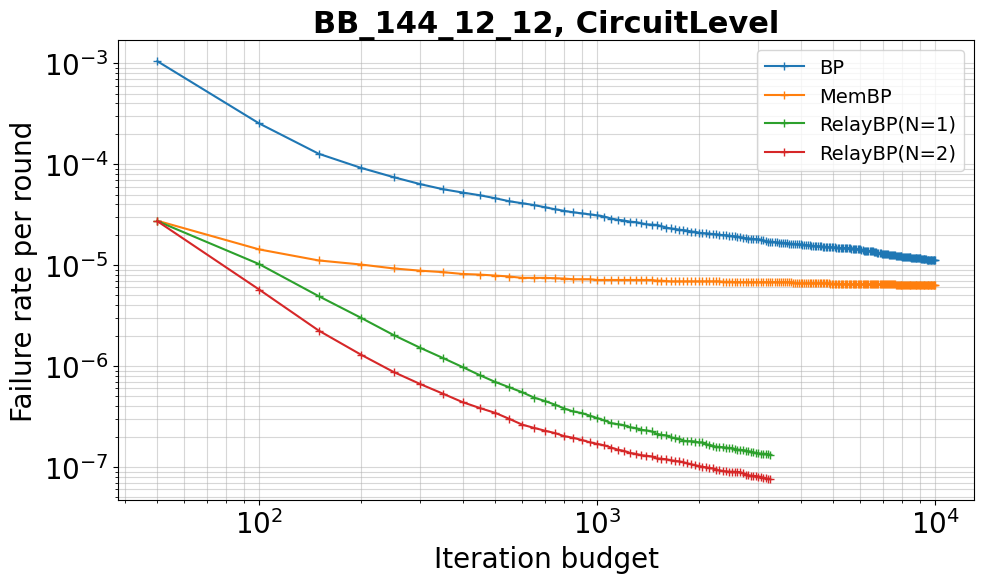

In [14]:
qec_params = QECParams(
    code="BB_144_12_12", noise_model="CircuitLevel", d=12, rounds=12, basis="Z"
)
physical_error_rate = 0.001
bp_kwargs = {"max_iter": 10000}
membp_kwargs = {"max_iter": 10000, "gamma": 0.2}
relaybp_kwargs = {
    "gamma0": 0.2,
    "gamma_dist_interval": [-0.19806670996164882, 0.6200937872049607],
    "num_relays": 64,
    "pre_iter": 50,
    "max_iter_per_relay": 50,
    "stop_nconv": 1,
    "num_indep_decoders": 1,
}
loaded_stats = load_stats(
    qec_params=qec_params,
    decoder_name_to_kwargs={
        "BP": [bp_kwargs],
        "MemBP": [membp_kwargs],
        "RelayBP": [relaybp_kwargs, {**relaybp_kwargs, "num_indep_decoders": 2}],
    },
    physical_error_rates=[physical_error_rate],
)
print(f"Loaded {len(loaded_stats)} benchmark entries")

plot_fr_vs_iter_budget(
    loaded_stats, qec_params=qec_params, x_metric="iter_budget", y_metric="fr_per_round"
)


# 3. Rotated surface code d=11, circuit-level noise, basis=Z, p=0.001

Loaded 4 benchmark entries


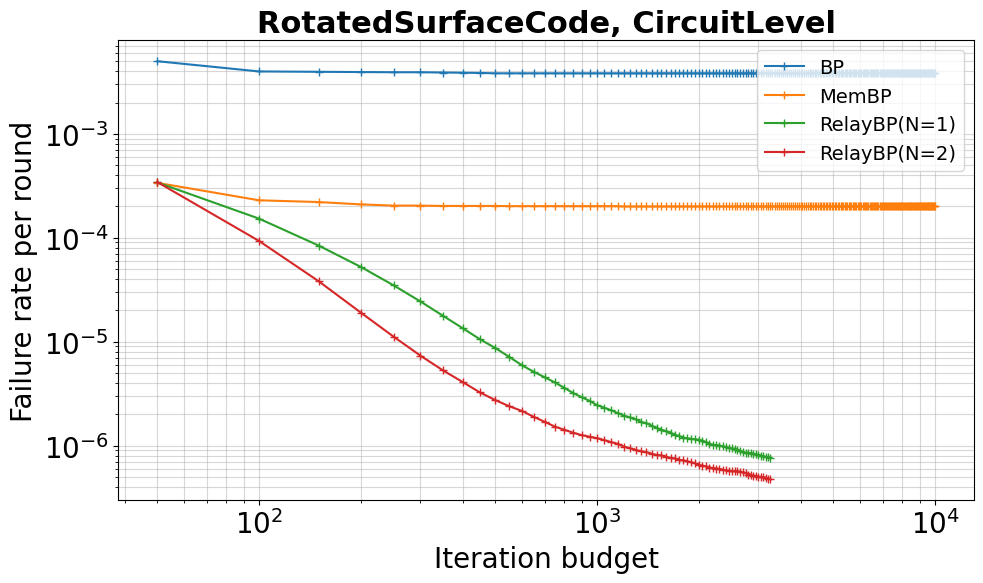

In [15]:
qec_params = QECParams(
    code="RotatedSurfaceCode", noise_model="CircuitLevel", d=11, rounds=11, basis="Z"
)
physical_error_rate = 0.001
bp_kwargs = {"max_iter": 10000}
membp_kwargs = {"max_iter": 10000, "gamma": 0.55}
relaybp_kwargs = {
    "gamma0": 0.55,
    "gamma_dist_interval": [-0.2526669073577039, 0.9575754453501071],
    "num_relays": 64,
    "pre_iter": 50,
    "max_iter_per_relay": 50,
    "stop_nconv": 1,
    "num_indep_decoders": 1,
}
loaded_stats = load_stats(
    qec_params=qec_params,
    decoder_name_to_kwargs={
        "BP": [bp_kwargs],
        "MemBP": [membp_kwargs],
        "RelayBP": [relaybp_kwargs, {**relaybp_kwargs, "num_indep_decoders": 2}],
    },
    physical_error_rates=[physical_error_rate],
)
print(f"Loaded {len(loaded_stats)} benchmark entries")

plot_fr_vs_iter_budget(
    loaded_stats, qec_params=qec_params, x_metric="iter_budget", y_metric="fr_per_round"
)


# 4. Rotated surface code d=11, phenomenological noise, basis=Z, p=0.001

Loaded 5 benchmark entries


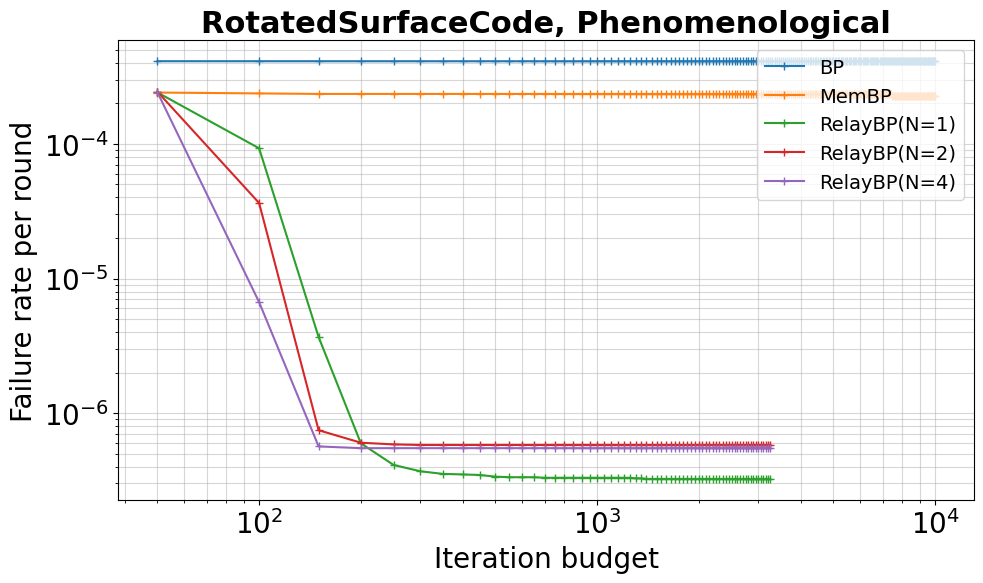

In [18]:
qec_params = QECParams(
    code="RotatedSurfaceCode",
    noise_model="Phenomenological",
    d=11,
    rounds=11,
    basis="Z",
)
physical_error_rate = 0.001
bp_kwargs = {"max_iter": 10000}
membp_kwargs = {"max_iter": 10000, "gamma": 0.55}
dmembp_kwargs = {"use_prior_in_ckpt": True, "max_iter": 10000}
relaybp_kwargs = {
    "gamma0": 0.55,
    "gamma_dist_interval": [-0.2249502476717961, 0.7537800632074495],
    "num_relays": 64,
    "pre_iter": 50,
    "max_iter_per_relay": 50,
    "stop_nconv": 1,
    "num_indep_decoders": 1,
}
loaded_stats = load_stats(
    qec_params=qec_params,
    decoder_name_to_kwargs={
        "BP": [bp_kwargs],
        "MemBP": [membp_kwargs],
        "LearnedDMemBP/run_0": [dmembp_kwargs],
        "RelayBP": [
            relaybp_kwargs,
            {**relaybp_kwargs, "num_indep_decoders": 2},
            {**relaybp_kwargs, "num_indep_decoders": 4},
        ],
    },
    physical_error_rates=[physical_error_rate],
)
print(f"Loaded {len(loaded_stats)} benchmark entries")

plot_fr_vs_iter_budget(
    loaded_stats, qec_params=qec_params, x_metric="iter_budget", y_metric="fr_per_round"
)


# 5. Hexagonal color code d=11, phenomenological noise, basis=Z, p=0.005

Loaded 3 benchmark entries


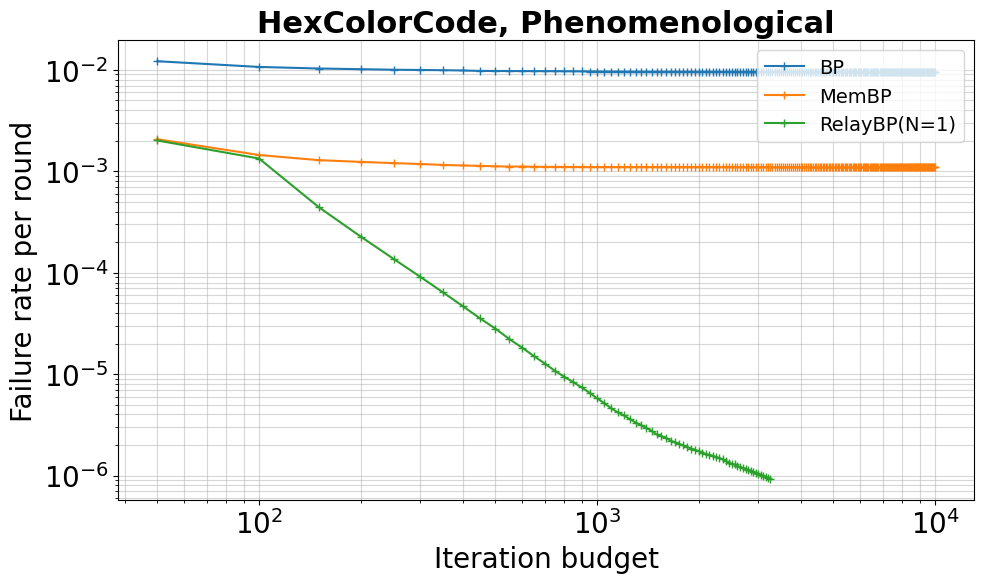

In [8]:
qec_params = QECParams(
    code="HexColorCode",
    noise_model="Phenomenological",
    d=11,
    rounds=11,
    basis="Z",
)
physical_error_rate = 0.005
bp_kwargs = {"max_iter": 10000}
membp_kwargs = {"max_iter": 10000, "gamma": 0.55}
relaybp_kwargs = {
    "gamma0": 0.55,
    "gamma_dist_interval": [-0.21295457674166532, 0.697918233656232],
    "num_relays": 64,
    "pre_iter": 50,
    "max_iter_per_relay": 50,
    "stop_nconv": 1,
    "num_indep_decoders": 1,
}
loaded_stats = load_stats(
    qec_params=qec_params,
    decoder_name_to_kwargs={
        "BP": [bp_kwargs],
        "MemBP": [membp_kwargs],
        "RelayBP": [relaybp_kwargs],
    },
    physical_error_rates=[physical_error_rate],
)
print(f"Loaded {len(loaded_stats)} benchmark entries")

plot_fr_vs_iter_budget(
    loaded_stats, qec_params=qec_params, x_metric="iter_budget", y_metric="fr_per_round"
)
